# NCC example - Notebook 6.1

In [2]:
import os
import numpy as np

Creiamo un set di immagini, utilizzando una libreria predefinita. Si tratta delle cifre da 0 a 9. Vengono generate 1797 immagini ognuna leggermente diversa dall'altra. 

In [3]:
from sklearn.datasets import load_digits
digits = load_digits()
images, labels = digits.images, digits.target

Visualizziamo le prime 10 immagini

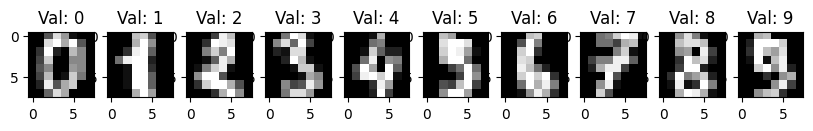

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for k in range(10):
    plt.subplot(1, 10, k+1)
    plt.imshow(images[k,:,:], cmap='gray')
    plt.title(f"Val: {labels[k]}")

Dividiamo le immagini in training e validation test in modo casuale

In [9]:
# dividiamo le immagini in training e validation 
from sklearn.model_selection import train_test_split
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

Implementiamo il classificatore NCC. Confrontiamo le immagini nel validation set con quelle nel training e troviamo la più simile. Usiamo come metrica l'RMSE

In [10]:
correct = 0
for k in range(len(val_imgs)):
    img_val = val_imgs[k]
    
    # Calcolo RMSE manuale (come sqrt(immse)) tra img_val e tutto il train_set
    # Usiamo NumPy per vettorizzare il calcolo (molto più veloce del loop for)
    distances = np.sqrt(np.mean((train_imgs - img_val)**2, axis=(1, 2)))
    
    best_match_idx = np.argmin(distances)
    predicted_label = train_labels[best_match_idx]
    
    if predicted_label == val_labels[k]:
        correct += 1

acc_val = (correct / len(val_imgs)) * 100
print(f"Accuracy Validation: {acc_val:.2f}%")

Accuracy Validation: 97.78%


Otteniamo un accuratezza molto alta (97.78 %). Proviamo a migliorarla con un k-NNC  

In [11]:
# K-NNC
from collections import Counter
K = 5
test_correct = 0


for k in range(len(val_imgs)):
    img_test = val_imgs[k]
    
    distances = np.sqrt(np.mean((train_imgs - img_test)**2, axis=(1, 2)))
    
    # Trova i K indici con le distanze minori
    best_k_indices = np.argsort(distances)[:K]
    best_labels = train_labels[best_k_indices]
    
    # Votazione (histcounts in MATLAB)
    most_common = Counter(best_labels).most_common(1)
    predicted_label = most_common[0][0]
    
    if predicted_label == val_labels[k]:
        test_correct += 1

acc_test_k = (test_correct / len(val_imgs)) * 100
print(f"Accuracy k-NNC (K={K}): {acc_test_k:.2f}%")

Accuracy k-NNC (K=5): 98.61%


Variando il valore di K (l'iperparametro del classificatore) possiamo incrementare l'accuratezza. Ad esempio, con k=5 abbiamo 98.61%. Per trovare l'iperparametro migliore in questo caso possiamo usare una ricerca esaustiva provando "tutti" i valori di K

In [13]:
# ottimizzazione iperparametri
accuracy=[] # inizializziamo una lista

for K in range(1,11):
    test_correct = 0

    for k in range(len(val_imgs)):
        img_test = val_imgs[k]    
        distances = np.sqrt(np.mean((train_imgs - img_test)**2, axis=(1, 2)))
    
        # Trova i K indici con le distanze minori
        best_k_indices = np.argsort(distances)[:K]
        best_labels = train_labels[best_k_indices]
    
        # Votazione 
        most_common = Counter(best_labels).most_common(1)
        predicted_label = most_common[0][0]
    
        if predicted_label == val_labels[k]:
            test_correct += 1

    acc_test_k = (test_correct / len(val_imgs)) * 100
    print(f"Accuracy k-NNC (K={K}): {acc_test_k:.2f}%")
    accuracy.append(acc_test_k)

Accuracy k-NNC (K=1): 97.78%
Accuracy k-NNC (K=2): 97.78%
Accuracy k-NNC (K=3): 98.33%
Accuracy k-NNC (K=4): 98.06%
Accuracy k-NNC (K=5): 98.61%
Accuracy k-NNC (K=6): 98.89%
Accuracy k-NNC (K=7): 98.89%
Accuracy k-NNC (K=8): 98.61%
Accuracy k-NNC (K=9): 98.06%
Accuracy k-NNC (K=10): 97.78%


Vediamo che il valore migliore si ottiene per K=6 e K=7, che sono i valori ottimi dell'iperparametro. Per semplicità abbiamo provato fino a K=10, per valori superiori l'accuratezza diminuisce. Ma è affidabile questo risultato o dipende dal caso, cioè dalla distribuzione dei dati tra training e validation fatta in modo casuale? 
Per verificare dovremmo provare a cambiare il valore del seed random, in questo esempio 42 (è fatto obbligo allo studente di sapere perchè si usa 42). Se usiamo altri seed i risultati saranno leggermente diversi. Per verificare che la stima dell'iperparametro K è corretta dovremmo ripetere N volte la procedura e dimostrare da un punto di vista statistico che per K=6/7 il miglioramento dell'accuratezza è statisticamente significativo.   